In [11]:
import pandas as pd
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
import numpy as np

In [12]:
df1 = pd.read_csv('../dataset/raw/regular_season_box_scores_2010_2024_part_1.csv')
df2 = pd.read_csv('../dataset/raw/regular_season_box_scores_2010_2024_part_2.csv')
df3 = pd.read_csv('../dataset/raw/regular_season_box_scores_2010_2024_part_3.csv')
df4 = pd.read_csv('../dataset/raw/regular_season_totals_2010_2024.csv')

df = pd.concat([df1, df2, df3], axis = 0)
df.dropna()
def convert_minutes(x):
    if pd.isna(x):
        return None
    try:
        minutes, seconds = map(int, x.split(':'))
        return minutes + seconds / 60
    except:
        return None

df['minutes'] = df['minutes'].apply(convert_minutes)
df['minutes']
df

,season_year,game_date,gameId,matchup,teamId,teamCity,teamName,teamTricode,teamSlug,personId,...,reboundsOffensive,reboundsDefensive,reboundsTotal,assists,steals,blocks,turnovers,foulsPersonal,points,plusMinusPoints
0,2010-11,2010-11-10,21000112,NJN @ CLE,1610612751,New Jersey,Nets,NJN,nets,693,...,0,0,0,0,0,0,0,0,0,-4
1,2010-11,2010-11-17,21000165,NJN @ UTA,1610612751,New Jersey,Nets,NJN,nets,693,...,0,0,0,0,0,0,0,0,0,0
2,2010-11,2010-11-27,21000237,NJN @ PHI,1610612751,New Jersey,Nets,NJN,nets,693,...,0,0,0,0,0,0,0,0,0,0
3,2010-11,2010-12-12,21000351,NJN vs. LAL,1610612751,New Jersey,Nets,NJN,nets,693,...,0,0,0,0,0,0,0,0,0,0
4,2010-11,2010-10-29,21000020,NJN vs. SAC,1610612751,New Jersey,Nets,NJN,nets,693,...,0,1,1,1,0,0,1,1,2,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141487,2023-24,2024-01-25,22300628,WAS vs. UTA,1610612764,Washington,Wizards,WAS,wizards,1641998,...,0,1,1,0,0,0,0,0,0,0
141488,2023-24,2024-01-21,22300602,WAS vs. DEN,1610612764,Washington,Wizards,WAS,wizards,1641998,...,0,0,0,0,0,0,0,0,0,0
141489,2023-24,2024-01-29,22300665,WAS @ SAS,1610612764,Washington,Wizards,WAS,wizards,1641998,...,0,0,0,0,0,0,0,0,0,0
141490,2023-24,2024-01-24,22300620,WAS vs. MIN,1610612764,Washington,Wizards,WAS,wizards,1641998,...,0,0,0,0,0,0,1,0,0,3


In [13]:
minutes_mean = df[['personId', 'personName', 'teamId', 'season_year', 'minutes']].groupby(by = ['personId','personName', 'teamId', 'season_year']).mean(numeric_only = True).reset_index()[['personId', 'personName', 'teamId', 'season_year', 'minutes']]

minutes_mean.rename(columns={'minutes': 'seasonMeanMinutes'}, inplace=True)

inliers = pd.merge(df, minutes_mean[['personId', 'teamId', 'seasonMeanMinutes']], on=['personId', 'teamId'], how='inner')

inliers = inliers[inliers['minutes'] >= inliers['seasonMeanMinutes']*0.75]
inliers = inliers[['gameId',
    "minutes",
    "fieldGoalsMade",
    "fieldGoalsAttempted",
    "fieldGoalsPercentage",
    "threePointersMade",
    "threePointersAttempted",
    "threePointersPercentage",
    "freeThrowsMade",
    "freeThrowsAttempted",
    "freeThrowsPercentage",
    "reboundsOffensive",
    "reboundsDefensive",
    "reboundsTotal",
    "assists",
    "steals",
    "blocks",
    "turnovers",
    "foulsPersonal",
    "points",
    "plusMinusPoints",
    "season_year"]]

In [21]:
grouped = df.groupby(by = ['personName', 'gameId', 'season_year']).sum(numeric_only = True).reset_index().drop(columns = ['jerseyNum'])

In [22]:
#inliers = inliers.head(20000)
inliers = inliers[inliers['season_year'] == '2022-23']
inliers_data = inliers[["minutes"]]

model = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
model.fit(inliers_data)

OneClassSVM(nu=0.05)

In [23]:
grouped = grouped[grouped['season_year'] == '2022-23']
#grouped = grouped.tail(20000)

grouped_data = grouped[["minutes"]]

scores = model.decision_function(grouped_data)

labels = model.predict(grouped_data)

grouped['anomaly_score'] = scores
grouped['anomaly_flag'] = labels

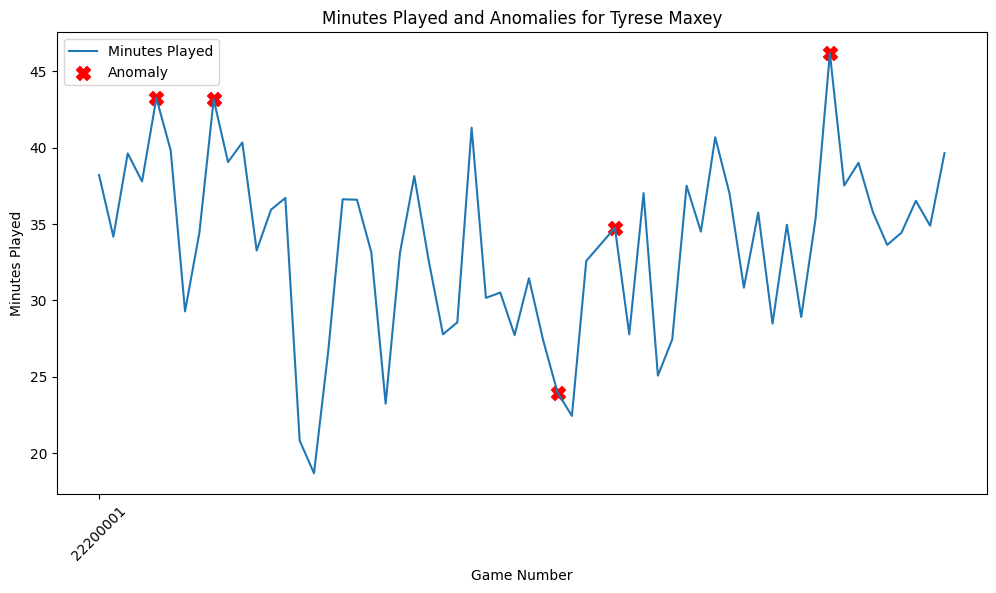

In [24]:
import matplotlib.pyplot as plt

player = 'Tyrese Maxey'
player_df = grouped[grouped['personName'] == player].sort_values('gameId')

x = range(len(player_df))

plt.figure(figsize=(12,6))
plt.plot(x, player_df['minutes'], label='Minutes Played')

anomaly_idx = player_df[player_df['anomaly_flag'] == -1].index
anomaly_pos = [player_df.index.get_loc(i) for i in anomaly_idx]

plt.scatter(anomaly_pos,
            player_df.loc[anomaly_idx, 'minutes'],
            color='red', label='Anomaly', s=100, marker='X')

plt.xlabel('Game Number')
plt.ylabel('Minutes Played')
plt.title(f'Minutes Played and Anomalies for {player}')
plt.legend()

tick_locs = list(range(0, len(player_df), 1000))
tick_labels = player_df['gameId'].astype(str).iloc[tick_locs]

plt.xticks(tick_locs, tick_labels, rotation=45)
plt.show()

In [29]:
grouped = pd.merge(grouped, minutes_mean[['personId', 'teamId', 'seasonMeanMinutes']], on=['personId', 'teamId'], how='inner')

In [30]:
grouped.head(0)

,personName,gameId,season_year,teamId,personId,minutes,fieldGoalsMade,fieldGoalsAttempted,fieldGoalsPercentage,threePointersMade,...,steals,blocks,turnovers,foulsPersonal,points,plusMinusPoints,anomaly_score,anomaly_flag,seasonMeanMinutes_x,seasonMeanMinutes_y


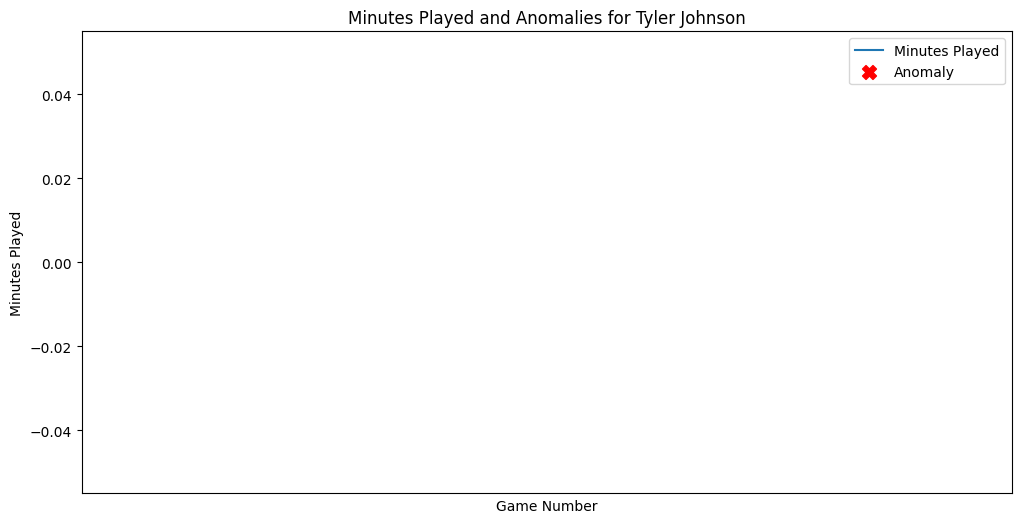

In [27]:
grouped = grouped[(grouped['minutes'] < grouped['seasonMeanMinutes'])]

player = 'Tyler Johnson'
player_df = grouped[grouped['personName'] == player].sort_values('gameId')

x = range(len(player_df))

plt.figure(figsize=(12,6))
plt.plot(x, player_df['minutes'], label='Minutes Played')

anomaly_idx = player_df[player_df['anomaly_flag'] == -1].index
anomaly_pos = [player_df.index.get_loc(i) for i in anomaly_idx]

plt.scatter(anomaly_pos,
            player_df.loc[anomaly_idx, 'minutes'],
            color='red', label='Anomaly', s=100, marker='X')

plt.xlabel('Game Number')
plt.ylabel('Minutes Played')
plt.title(f'Minutes Played and Anomalies for {player}')
plt.legend()

tick_locs = list(range(0, len(player_df), 1000))
tick_labels = player_df['gameId'].astype(str).iloc[tick_locs]

plt.xticks(tick_locs, tick_labels, rotation=45)
plt.show()
# Para cada jogador
# Verificar se existem 3 jogos seguidos com anomalias

# Ver o impacto de esse jogador estar fora nos 3 jogos

In [ ]:
new_df = grouped.merge(season_year, on="gameId", how="left")
merged_df = new_df.merge(minutes_mean, on=["personName", "season_year"], how="left")

merged_df.to_csv('../dataset/clean/players_with_anomaly.csv')